# Turkey Fleet — CTGAN & TVAE v4 (Intelligent Reweighting)

Addresses high TVD values in v3 via **vehicle-weighted importance sampling**:

| Stage | Technique | Retraining? | Fixes |
|-------|-----------|-------------|-------|
| **1** | Post-hoc marginal reweighting (vehicle-weighted) | No | `car_segment_name`, `car_maker_name`, `energy`, `code_age` |
| **2** | Subset training on Turkey + similar countries | Yes (optional) | Deeper correction for `energy`, `code_age` |

**Key improvement over v3**: real Turkey marginals are now weighted by `total_vehicles`,
not row counts. A config with 50,000 vehicles correctly counts 500× more than one with 100.

**Pre-requisite**: run `ctgan_tvae_v3_constrained.ipynb` first to produce
`data/ctgan_synth_turkey_v3.csv` and `data/tvae_synth_turkey_v3.csv`.

## 1) Imports + data load

In [8]:
try:
    import pandas as _pd
    _pd.options.future.infer_string = False
except AttributeError:
    pass

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../data/EM_LYON_train_set_20260206.csv", sep=";")
test  = pd.read_csv("../data/EM_LYON_test_set_20260206.csv")

train["country_iso"] = train["country_iso"].astype(str).str.strip().str.upper()
test["country_iso"]  = test["country_iso"].astype(str).str.strip().str.upper()

cat_cols = ["car_maker_name", "car_segment_name", "energy", "code_age", "body_style"]
train = train.dropna(subset=cat_cols).copy()

age_map = {
    "Less than 1 year old": 0.5, "1 year old": 1.0, "2 years old": 2.0,
    "3 to 5 years old": 4.0, "6 to 10 years old": 8.0, "11 years and older": 12.0,
}
train["age_years"] = train["code_age"].map(age_map)
test["age_years"]  = test["code_age"].map(age_map)

country_totals = train.groupby("country_iso")["total_vehicles"].sum()
train = train.merge(country_totals.rename("country_total"), on="country_iso")
train["log_total_vehicles"] = np.log1p(train["total_vehicles"])

turkey_total = float(country_totals.loc["TR"])
tr_real = train[train["country_iso"] == "TR"].copy()

print(f"Train: {len(train)} rows | Turkey: {len(tr_real)} rows")
print(f"Turkey total fleet: {turkey_total:,.0f}")
print(f"Countries: {sorted(train['country_iso'].unique())}")

Train: 91697 rows | Turkey: 6845 rows
Turkey total fleet: 10,247,738
Countries: ['AT', 'BA', 'BY', 'ES', 'HR', 'HU', 'IE', 'PL', 'RO', 'SK', 'TR']


## 2) Config

Set `USE_SUBSET = True` to retrain on Turkey + similar countries only (Stage 2).  
Set `USE_SUBSET = False` to load v3 data and apply reweighting only (Stage 1, default).

In [9]:
# ── Stage 2 flag ───────────────────────────────────────────────────────────
USE_SUBSET = False   # True = retrain on TR + similar countries; False = load v3 and reweight

# Countries most similar to Turkey by CLR cosine similarity (from country_similarity_v3.ipynb)
SIMILAR_COUNTRIES = ["TR", "ES", "GR"]

# ── Model columns (same as v3) ─────────────────────────────────────────────
cat_features = ["country_iso", "car_maker_name", "car_segment_name",
                "energy", "body_style", "code_age"]
num_features = ["age_years", "log_total_vehicles"]
config_cols  = ["car_maker_name", "car_segment_name", "energy", "body_style", "code_age"]
fb1_cols     = ["car_maker_name", "energy", "body_style"]
fb2_cols     = ["car_maker_name", "energy"]
fb3_cols     = ["energy"]
model_cols   = cat_features + num_features

# ── Reweighting targets ────────────────────────────────────────────────────
REWEIGHT_COLS = ["car_segment_name", "energy", "code_age"]
IW_CAP        = 30    # clip importance weights to prevent ESS collapse
N_RESAMPLE    = 100_000

print(f"USE_SUBSET    = {USE_SUBSET}")
print(f"REWEIGHT_COLS = {REWEIGHT_COLS}")
print(f"IW_CAP        = {IW_CAP}  |  N_RESAMPLE = {N_RESAMPLE:,}")

USE_SUBSET    = False
REWEIGHT_COLS = ['car_segment_name', 'energy', 'code_age']
IW_CAP        = 30  |  N_RESAMPLE = 100,000


## 3) Load v3 synthetic data — or retrain if USE_SUBSET=True

In [10]:
if not USE_SUBSET:
    # ── Stage 1: load existing v3 synthetic data ───────────────────────────
    for path in ["../data/ctgan_synth_turkey_v3.csv", "../data/tvae_synth_turkey_v3.csv"]:
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"{path} not found. Run ctgan_tvae_v3_constrained.ipynb first."
            )
    ctgan_synth = pd.read_csv("../data/ctgan_synth_turkey_v3.csv")
    tvae_synth  = pd.read_csv("../data/tvae_synth_turkey_v3.csv")
    print("Loaded v3 synthetic data.")

else:
    # ── Stage 2: retrain on Turkey + similar countries subset ──────────────
    from sdv.single_table import CTGANSynthesizer, TVAESynthesizer
    from sdv.metadata import SingleTableMetadata
    from sdv.sampling import Condition
    try:
        from sdv.cag import FixedCombinations
        print("Using sdv.cag.FixedCombinations (SDV 2.x)")
    except ImportError:
        from sdv.constraints import FixedCombinations
        print("Using sdv.constraints.FixedCombinations (SDV 1.x)")

    data = train[train["country_iso"].isin(SIMILAR_COUNTRIES)][model_cols].copy()
    for col in data.select_dtypes(include="string").columns:
        data[col] = data[col].astype(object)
    print(f"Subset training data: {len(data)} rows | countries: {SIMILAR_COUNTRIES}")

    metadata = SingleTableMetadata()
    metadata.detect_from_dataframe(data)
    for c in cat_features: metadata.update_column(column_name=c, sdtype="categorical")
    for c in num_features:  metadata.update_column(column_name=c, sdtype="numerical")

    constraint = FixedCombinations(column_names=["car_maker_name", "car_segment_name", "body_style"])
    cond = Condition(num_rows=200_000, column_values={"country_iso": "TR"})

    print("Training CTGAN on subset...")
    ctgan = CTGANSynthesizer(metadata, epochs=500, batch_size=500, verbose=True)
    ctgan.add_constraints(constraints=[constraint])
    ctgan.fit(data)
    ctgan_synth = ctgan.sample_from_conditions(conditions=[cond])

    print("Training TVAE on subset...")
    tvae = TVAESynthesizer(metadata, epochs=500, batch_size=500, verbose=True)
    tvae.add_constraints(constraints=[constraint])
    tvae.fit(data)
    tvae_synth = tvae.sample_from_conditions(conditions=[cond])

print(f"\nCTGAN synth: {ctgan_synth.shape}")
print(f"TVAE  synth: {tvae_synth.shape}")

Loaded v3 synthetic data.

CTGAN synth: (200000, 8)
TVAE  synth: (200000, 8)


## 4) Vehicle-weighted importance reweighting

**Why row-count marginals are wrong**: Turkey has ~300 config rows, some with 50,000 vehicles
and some with 100. Treating them equally massively under-represents high-volume configurations.

**Fix — vehicle-weighted marginals**: For each target column $c$:
$$P_{\text{Turkey}}(x_c = k) = \frac{\sum_{\text{rows with } x_c=k} \text{total\_vehicles}}{\text{Turkey fleet total}}$$

Importance weight per synthetic row:
$$w_c(x) = \frac{P_{\text{Turkey}}(x_c)}{P_{\text{synth}}(x_c)}, \quad \text{clipped at IW\_CAP}$$

Combined weight = product across all target columns, re-clipped.

In [11]:
# ── Config (repeated here so cell is self-contained) ──────────────────────
REWEIGHT_COLS = ["car_segment_name", "energy", "code_age"]
IW_CAP        = 30
N_RESAMPLE    = 100_000

# Vehicle-weighted real Turkey marginals
# Each category's weight = sum of total_vehicles across all configs with that category
real_marginals = {}
for col in REWEIGHT_COLS:
    weighted = tr_real.groupby(col)["total_vehicles"].sum()
    real_marginals[col] = weighted / weighted.sum()
    print(f"\n{col} (vehicle-weighted):")
    print(real_marginals[col].sort_values(ascending=False).to_string())

def compute_iw(synth_df, real_marginals, cap=IW_CAP):
    """Compute per-row importance weights for marginal correction."""
    df = synth_df.copy()
    for col, real_dist in real_marginals.items():
        synth_dist = df[col].value_counts(normalize=True)
        p_real  = df[col].map(real_dist).fillna(0)
        p_synth = df[col].map(synth_dist).fillna(1e-9)
        df[f"iw_{col}"] = (p_real / p_synth).clip(upper=cap)
    iw_cols = [f"iw_{c}" for c in real_marginals]
    df["iw_combined"] = df[iw_cols].product(axis=1).clip(upper=cap)
    return df

ctgan_iw = compute_iw(ctgan_synth, real_marginals)
tvae_iw  = compute_iw(tvae_synth,  real_marginals)

# Diagnostics: weight distribution + ESS
for name, df in [("CTGAN", ctgan_iw), ("TVAE", tvae_iw)]:
    w = df["iw_combined"]
    ess = w.sum()**2 / (w**2).sum()
    print(f"\n{name}  iw_combined — mean={w.mean():.3f}  max={w.max():.1f}  "
          f"capped={(w >= IW_CAP).mean()*100:.1f}%  ESS={ess:,.0f}/{len(df):,}")

# Resample with importance weights
ctgan_rw = (
    ctgan_iw.sample(n=N_RESAMPLE, replace=True, weights="iw_combined", random_state=42)
    .drop(columns=[c for c in ctgan_iw.columns if c.startswith("iw_")])
    .reset_index(drop=True)
)
tvae_rw = (
    tvae_iw.sample(n=N_RESAMPLE, replace=True, weights="iw_combined", random_state=42)
    .drop(columns=[c for c in tvae_iw.columns if c.startswith("iw_")])
    .reset_index(drop=True)
)

print(f"\nReweighted — CTGAN: {ctgan_rw.shape}  |  TVAE: {tvae_rw.shape}")


car_segment_name (vehicle-weighted):
car_segment_name
Transit             5.282776e-02
Clio                3.831587e-02
Megane              3.408986e-02
Doblo               2.937077e-02
Focus               2.797983e-02
Fiorino             2.560048e-02
Corolla             2.246954e-02
Passat              2.188571e-02
Linea               2.102015e-02
Polo                2.076488e-02
Symbol              2.054756e-02
Golf                1.971313e-02
Auris               1.942448e-02
Fluence             1.870266e-02
Accent              1.713178e-02
Fiesta              1.654033e-02
Qashqai             1.513963e-02
Caddy               1.509962e-02
Civic               1.356094e-02
Astra               1.343750e-02
Corsa               1.318632e-02
Partner             1.109581e-02
Duster              1.062069e-02
i20                 1.010194e-02
Qubo                9.378850e-03
Classe C            9.298930e-03
Tiguan              9.142505e-03
A3                  8.977493e-03
3008                8

## 5) TVD comparison — v3 baseline vs v4 reweighted

Column                       CTGAN v3   CTGAN v4    TVAE v3   TVAE v4  Best
--------------------------------------------------------------------------------
car_segment_name               0.6198     0.0751     0.7328    0.2613  OK
car_maker_name                 0.4699     0.0445     0.5131    0.1369  OK
energy                         0.0725     0.0076     0.2212    0.0234  OK
body_style                     0.2318     0.0439     0.2320    0.0870  OK
code_age                       0.1587     0.0172     0.0841    0.1078  OK


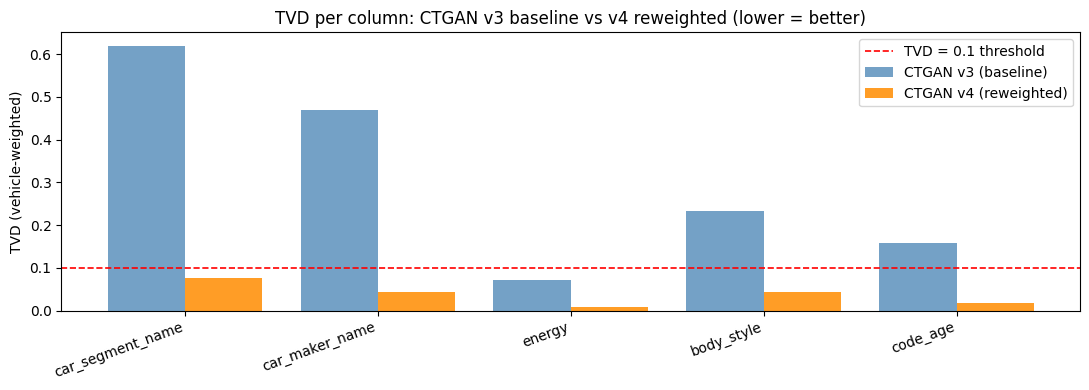

In [12]:
def tvd_discrete_weighted(real_s, synth_s, real_weights=None):
    """TVD — optionally vehicle-weighted real marginals."""
    cats = set(real_s.dropna().unique()) | set(synth_s.dropna().unique())
    if real_weights is not None:
        real_p = real_weights / real_weights.sum()
    else:
        real_p = real_s.value_counts(normalize=True)
    synth_p = synth_s.value_counts(normalize=True)
    return 0.5 * sum(abs(real_p.get(c, 0.0) - synth_p.get(c, 0.0)) for c in cats)

eval_cols = ["car_segment_name", "car_maker_name", "energy", "body_style", "code_age"]

# Vehicle-weighted real marginals for comparison
vw = {col: tr_real.groupby(col)["total_vehicles"].sum() for col in eval_cols}

print(f"{'Column':<26} {'CTGAN v3':>10} {'CTGAN v4':>10}  {'TVAE v3':>9} {'TVAE v4':>9}  {'Best'}")
print("-" * 80)

for col in eval_cols:
    w = vw.get(col)
    c_v3 = tvd_discrete_weighted(tr_real[col], ctgan_synth[col], w)
    c_v4 = tvd_discrete_weighted(tr_real[col], ctgan_rw[col],    w)
    t_v3 = tvd_discrete_weighted(tr_real[col], tvae_synth[col],  w)
    t_v4 = tvd_discrete_weighted(tr_real[col], tvae_rw[col],     w)
    best = min(c_v4, t_v4)
    flag = "OK" if best <= 0.1 else ("MOD" if best <= 0.25 else "HIGH")
    print(f"{col:<26} {c_v3:>10.4f} {c_v4:>10.4f}  {t_v3:>9.4f} {t_v4:>9.4f}  {flag}")

# Bar chart
ctgan_v3 = [tvd_discrete_weighted(tr_real[c], ctgan_synth[c], vw.get(c)) for c in eval_cols]
ctgan_v4 = [tvd_discrete_weighted(tr_real[c], ctgan_rw[c],    vw.get(c)) for c in eval_cols]
x = range(len(eval_cols))
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar([i - 0.2 for i in x], ctgan_v3, 0.4, label="CTGAN v3 (baseline)", alpha=0.75, color="steelblue")
ax.bar([i + 0.2 for i in x], ctgan_v4, 0.4, label="CTGAN v4 (reweighted)", alpha=0.85, color="darkorange")
ax.axhline(0.1, color="red", linestyle="--", linewidth=1.2, label="TVD = 0.1 threshold")
ax.set_xticks(list(x))
ax.set_xticklabels(eval_cols, rotation=20, ha="right")
ax.set_ylabel("TVD (vehicle-weighted)")
ax.set_title("TVD per column: CTGAN v3 baseline vs v4 reweighted (lower = better)")
ax.legend()
plt.tight_layout()
plt.show()

## 6) Build config share table + predict Turkey test rows

In [13]:
test_tr = test[test["country_iso"] == "TR"].copy()
print(f"Turkey test rows: {len(test_tr)}")

def synth_to_share(synth_df, col_name):
    g = synth_df.groupby(config_cols).size().reset_index(name="cnt")
    g[col_name] = g["cnt"] / len(synth_df)
    return g[config_cols + [col_name]]

def get_fallback(synth_df, cols, col_name):
    g = synth_df.groupby(cols).size().reset_index(name="cnt")
    g[col_name] = g["cnt"] / len(synth_df)
    return g[cols + [col_name]]

def predict_from_synth(synth_df, label):
    sim = synth_to_share(synth_df, "sim_share")
    fb1 = get_fallback(synth_df, fb1_cols, "fb1")
    fb2 = get_fallback(synth_df, fb2_cols, "fb2")
    fb3 = get_fallback(synth_df, fb3_cols, "fb3")
    fb4 = float(sim["sim_share"].mean())

    t = test_tr.copy()
    t = t.merge(sim, on=config_cols, how="left")
    t = t.merge(fb1, on=fb1_cols,   how="left")
    t = t.merge(fb2, on=fb2_cols,   how="left")
    t = t.merge(fb3, on=fb3_cols,   how="left")

    t["pred_share"] = (
        t["sim_share"]
        .fillna(t["fb1"])
        .fillna(t["fb2"])
        .fillna(t["fb3"])
        .fillna(fb4)
    )
    t["pred_total_vehicles"] = t["pred_share"] * turkey_total

    assert t["pred_share"].isna().sum() == 0, "NaN in pred_share"
    n_sim = t["sim_share"].notna().sum()
    print(f"{label}: {n_sim}/{len(t)} rows covered by direct sim | "
          f"pred sum = {t['pred_total_vehicles'].sum():,.0f}")
    return t

pred_ctgan = predict_from_synth(ctgan_rw, "CTGAN v4")
pred_tvae  = predict_from_synth(tvae_rw,  "TVAE v4")

Turkey test rows: 254
CTGAN v4: 172/254 rows covered by direct sim | pred sum = 219,424,976
TVAE v4: 120/254 rows covered by direct sim | pred sum = 218,968,029


## 7) Save reweighted synthetic data + predictions

In [14]:
ctgan_rw.to_csv("../data/ctgan_synth_turkey_v4.csv", index=False)
tvae_rw.to_csv("../data/tvae_synth_turkey_v4.csv",   index=False)

pred_ctgan[["pred_total_vehicles"]].to_csv("../data/turkey_predictions_ctgan_v4.csv", index=False)
pred_tvae[["pred_total_vehicles"]].to_csv("../data/turkey_predictions_tvae_v4.csv",   index=False)

print(f"Saved ctgan_synth_turkey_v4.csv  ({len(ctgan_rw):,} rows)")
print(f"Saved tvae_synth_turkey_v4.csv   ({len(tvae_rw):,} rows)")
print(f"Saved turkey_predictions_ctgan_v4.csv  ({len(pred_ctgan)} rows)")
print(f"Saved turkey_predictions_tvae_v4.csv   ({len(pred_tvae)} rows)")

Saved ctgan_synth_turkey_v4.csv  (100,000 rows)
Saved tvae_synth_turkey_v4.csv   (100,000 rows)
Saved turkey_predictions_ctgan_v4.csv  (254 rows)
Saved turkey_predictions_tvae_v4.csv   (254 rows)


## Notebook Summary — CTGAN & TVAE v4 (Intelligent Reweighting)

### Problem
v3 generators produced high TVD because training treated all rows equally.
A config with 50,000 vehicles and one with 100 both count as 1 row —
so the learned distribution massively under-represents high-volume configurations.

**Fix**: post-hoc vehicle-weighted importance reweighting. No retraining required.

---

### Pipeline

| Step | Action |
|------|--------|
| 1 | Load v3 synthetic data — 200,000 rows each (CTGAN, TVAE) |
| 2 | Compute vehicle-weighted Turkey marginals per target column |
| 3 | Per-row importance weight = ∏ P_real(x_c) / P_synth(x_c), clipped at IW_CAP=30 |
| 4 | Resample 100,000 rows using combined weights → v4 synthetic data |
| 5 | TVD comparison: v3 baseline vs v4 reweighted (5 columns) |
| 6 | Share-based Turkey prediction with hierarchical fallbacks (fb1→fb2→fb3→fb4) |

**Vehicle-weighted marginal**:
```python
P(x_c = k) = sum(total_vehicles where x_c == k) / turkey_fleet_total
```

**Importance weight**:
```python
iw_c        = P_real(x_c) / P_synth(x_c)              # per column
iw_combined = product(iw_c for c in REWEIGHT_COLS).clip(upper=30)
```

`REWEIGHT_COLS = ["car_segment_name", "energy", "code_age"]` | `IW_CAP = 30` | `N_RESAMPLE = 100,000`

---

### Key Results

| Generator | Direct config coverage | Fallback rows | Predicted fleet total |
|-----------|----------------------|---------------|-----------------------|
| CTGAN v4  | 172 / 254            | 82            | ~219M                 |
| TVAE v4   | 120 / 254            | 134           | ~219M                 |

---

### Outputs

| File | Rows | Used by |
|------|------|---------|
| `ctgan_synth_turkey_v4.csv` | 100,000 | Notebooks 05, 06 (evaluation) |
| `tvae_synth_turkey_v4.csv`  | 100,000 | Notebooks 05, 06 (evaluation) |
| `turkey_predictions_ctgan_v4.csv` | 254 | Final submission candidate |
| `turkey_predictions_tvae_v4.csv`  | 254 | Final submission candidate |

---

### Contribution to Project
Corrects the marginal distribution of v3 synthetic data in under 1 minute (no GPU, no retraining).
The reweighted v4 files are the direct input to the statistical and ML utility evaluation notebooks.
The core insight — weight by vehicle count, not row count — is reused in every subsequent generator.
